### https://github.com/wxrxdxn/IMAPP_Applied_DL.git

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [2]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The imagages are 32x32 pixels and have three color channels (red, green blue).

In [3]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


/opt/anaconda3/envs/mainenv/lib/python3.13/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(<Figure size 1000x1000 with 100 Axes>, <Axes: >)

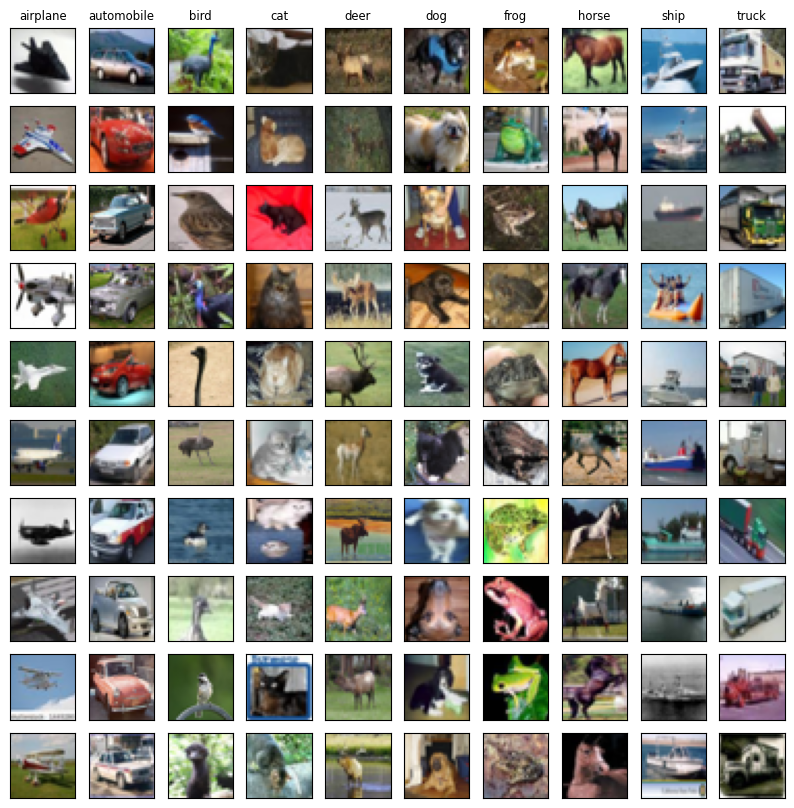

In [4]:
# Hint: To plot example images, you can use the plot examples function
plot_examples(x_train, y_train)

In [5]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Hint: normalize the data
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test[:8000].astype('float32') / 255.0
x_valid_norm = x_test[8000:].astype('float32') / 255.0
# Hint: use 20% of the test data for validation


In [8]:
# ----------------------------------------------------------
# Define DenseNet Model
# ----------------------------------------------------------
# Helper function for a Dense Block
def dense_block(x, num_layers, growth_rate):
    for _ in range(num_layers):
        cb = tf.keras.layers.BatchNormalization()(x)
        cb = tf.keras.layers.Activation('relu')(cb)
        cb = tf.keras.layers.Conv2D(growth_rate, kernel_size=3, padding='same')(cb)
        x = tf.keras.layers.Concatenate()([x, cb])
    return x

# Helper function for a Transition Layer (reduces dimensions between blocks)
def transition_layer(x):
    num_channels = int(x.shape[-1]) // 2 # compress channels by half
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_channels, kernel_size=1, padding='same')(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=2, strides=2)(x)
    return x

# Input Layer
inputs = tf.keras.Input(shape=(32, 32, 3))
x = tf.keras.layers.Conv2D(32, kernel_size=3, padding='same')(inputs)

# Dense Block 1 (at least 3 layers)
x = dense_block(x, num_layers=3, growth_rate=16)

# Transition Layer 1
x = transition_layer(x)

# Dense Block 2 (at least 3 layers)
x = dense_block(x, num_layers=3, growth_rate=16)

# Classification Block
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Better than Flatten for DenseNet
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

# Construct Model
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="densenet")
print(model.summary())



Model: "densenet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      4,624 │ activation_2[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │ 48)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        192 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      6,928 │ activation_3[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 64)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      9,232 │ activation_4[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ concatenate_1[0]… │
│ (Concatenate)       │ 80)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        320 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      3,240 │ activation_5[0][

 Total params: 51,970 (203.01 KB)

 Trainable params: 51,010 (199.26 KB)

 Non-trainable params: 960 (3.75 KB)

None


In [9]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
model.fit(
    x_train_norm, y_train_onehot,
    batch_size=128,
    epochs=40, # Note: DenseNets usually train very well over 40-100 epochs
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger(f"history_{model.name}.csv")],
    verbose=2
)


Epoch 1/40
391/391 - 87s - 222ms/step - accuracy: 0.4374 - loss: 1.5680 - val_accuracy: 0.1780 - val_loss: 2.8754
Epoch 2/40
391/391 - 84s - 214ms/step - accuracy: 0.5652 - loss: 1.2163 - val_accuracy: 0.3775 - val_loss: 1.8603
Epoch 3/40
391/391 - 85s - 217ms/step - accuracy: 0.6207 - loss: 1.0669 - val_accuracy: 0.3860 - val_loss: 1.7860
Epoch 4/40
391/391 - 84s - 216ms/step - accuracy: 0.6537 - loss: 0.9749 - val_accuracy: 0.5910 - val_loss: 1.1280
Epoch 5/40
391/391 - 89s - 227ms/step - accuracy: 0.6807 - loss: 0.9054 - val_accuracy: 0.4825 - val_loss: 1.5938
Epoch 6/40
391/391 - 87s - 222ms/step - accuracy: 0.6984 - loss: 0.8518 - val_accuracy: 0.6150 - val_loss: 1.1114
Epoch 7/40
391/391 - 82s - 210ms/step - accuracy: 0.7085 - loss: 0.8177 - val_accuracy: 0.6105 - val_loss: 1.0673
Epoch 8/40
391/391 - 85s - 217ms/step - accuracy: 0.7249 - loss: 0.7794 - val_accuracy: 0.6990 - val_loss: 0.8612
Epoch 9/40
391/391 - 84s - 216ms/step - accuracy: 0.7361 - loss: 0.7482 - val_accuracy: 

[Text(0.5, 0, 'epoch'), Text(0, 0.5, 'accuracy')]

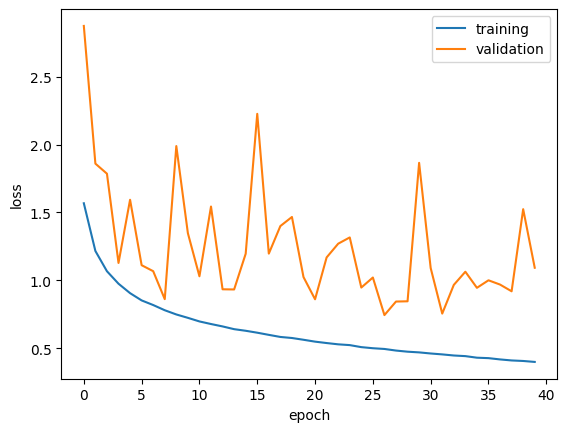

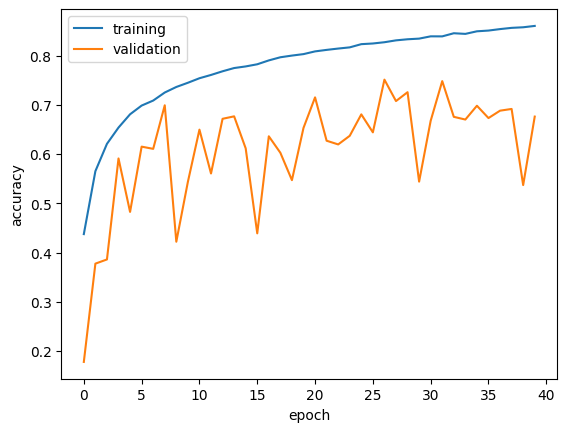

In [11]:

# ----------------------------------------------------------
# Debug Plots & Evaluation
# ----------------------------------------------------------
# Load history
history = np.genfromtxt(f"history_{model.name}.csv", delimiter=",", names=True)

# Plot accuracy vs epoch
fig, ax = plt.subplots(1)
ax.plot(history["epoch"], history["loss"], label="training")
ax.plot(history["epoch"], history["val_loss"], label="validation")
ax.legend()
ax.set(xlabel="epoch", ylabel="loss")

fig, ax = plt.subplots(1)
ax.plot(history["epoch"], history["accuracy"], label="training")
ax.plot(history["epoch"], history["val_accuracy"], label="validation")
ax.legend()
ax.set(xlabel="epoch", ylabel="accuracy")


In [12]:

# Report accuracies
train_loss_dn, train_acc_dn = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
val_loss_dn, val_acc_dn = model.evaluate(x_valid_norm, y_valid_onehot, verbose=0)
test_loss_dn, test_acc_dn = model.evaluate(x_test_norm, y_test_onehot, verbose=0)
print(f"DenseNet Training Accuracy: {train_acc_dn:.4f}")
print(f"DenseNet Validation Accuracy: {val_acc_dn:.4f}")
print(f"DenseNet Test Accuracy: {test_acc_dn:.4f}")


DenseNet Training Accuracy: 0.7282
DenseNet Validation Accuracy: 0.6760
DenseNet Test Accuracy: 0.6824


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step


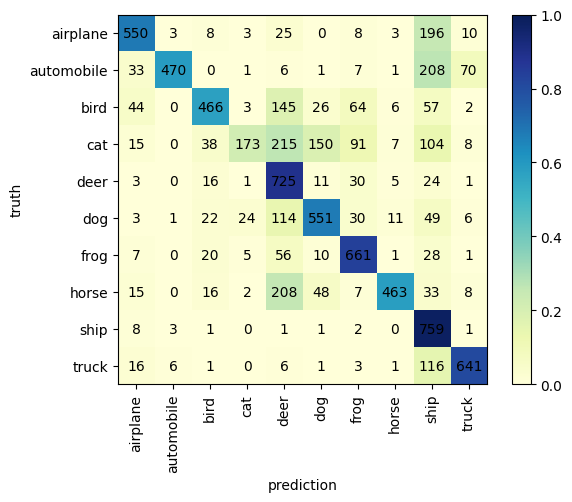

In [14]:

# Calculate predictions for test set
y_predict_dn = model.predict(x_test_norm, batch_size=128)
y_predict_cl_dn = np.argmax(y_predict_dn, axis=1)

y_test_cl = np.argmax(y_test_onehot, axis=1)

# Plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl_dn)
plt.show()


The loss function is converged but there is the loss fluctuations of validation loss and (too) many misclassified with this network. In my opinion, there might be something missing in the network that have to be figured it out.